**Movie Recommendation System 🎬**

In [ ]:
!pip3 install -q numpy pandas matplotlib plotly wordcloud scikit-learn

In [ ]:
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from wordcloud import WordCloud
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from scipy.sparse import save_npz
import warnings
warnings.filterwarnings('ignore')

In [ ]:
netflix_data = pd.read_csv("/content/netflix_data.csv")
netflix_data.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8154 entries, 0 to 8153
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8154 non-null   object
 1   type          8154 non-null   object
 2   title         8154 non-null   object
 3   director      5636 non-null   object
 4   cast          7407 non-null   object
 5   country       7351 non-null   object
 6   date_added    8145 non-null   object
 7   release_year  8154 non-null   int64 
 8   rating        8150 non-null   object
 9   duration      8150 non-null   object
 10  listed_in     8153 non-null   object
 11  description   8153 non-null   object
dtypes: int64(1), object(11)
memory usage: 764.6+ KB


In [ ]:
netflix_data.isnull().sum()

,0
show_id,0
type,0
title,0
director,2518
cast,747
country,803
date_added,9
release_year,0
rating,4
duration,4


In [ ]:
netflix_data.fillna('', inplace=True)
netflix_data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8154,8154,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8154,2,Movie,5597,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8154,8154,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,8154,4189,,2518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,8154,7130,,747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8154,685,United States,2571,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8154,1701,"January 1, 2020",79,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8154.0,NaN,NaN,NaN,2014.503066,8.411897,1925.0,2014.0,2017.0,2019.0,2021.0
rating,8154,18,TV-MA,3051,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8154,217,1 Season,1715,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Load the dataset
netflix_data = pd.read_csv('/content/netflix_data.csv')

# Check if 'release_year' column exists and contains numeric values
if 'release_year' in netflix_data.columns:
    netflix_data['release_year'] = pd.to_numeric(netflix_data['release_year'], errors='coerce')  # Convert to numeric

    # Count movies by release year
    movie_counts = netflix_data['release_year'].value_counts().sort_index()

    # Create the bar chart
    fig = go.Figure(data=go.Bar(x=movie_counts.index, y=movie_counts.values))

    fig.update_layout(
        plot_bgcolor='rgb(17, 17, 17)',
        paper_bgcolor='rgb(17, 17, 17)',
        font_color='white',
        title='Number of Movies Released Each Year',
        xaxis=dict(title='Year'),
        yaxis=dict(title='Number of Movies')
    )

    fig.update_traces(marker_color='red')
    fig.show()
else:
    print("Error: 'release_year' column not found in the dataset")


In [ ]:
movie_type_counts = netflix_data['type'].value_counts()

fig = go.Figure(data=go.Pie(labels=movie_type_counts.index, values=movie_type_counts.values))

fig.update_layout(
    plot_bgcolor='rgb(17, 17, 17)',
    paper_bgcolor='rgb(17, 17, 17)',
    font_color='white',
    title='Distribution of C. Types',
)
fig.update_traces(marker=dict(colors=['red']))
fig.show()

In [ ]:
top_countries = netflix_data['country'].value_counts().head(10)

fig = px.treemap(names=top_countries.index, parents=["" for _ in top_countries.index], values=top_countries.values)

fig.update_layout(
    plot_bgcolor='rgb(17, 17, 17)',
    paper_bgcolor='rgb(17, 17, 17)',
    font_color='white',
    title='Top Countries with Highest Number of Movies',
)
fig.show()

In [ ]:
country_movie_counts = netflix_data['country'].value_counts()

data = pd.DataFrame({'Country': country_movie_counts.index, 'Movie Count': country_movie_counts.values})

fig = px.choropleth(data_frame=data, locations='Country', locationmode='country names',
                    color='Movie Count', title='Number of Movies Released By Country',
                    color_continuous_scale='Reds', range_color=(0, data['Movie Count'].max()),
                    labels={'Movie Count': 'Number of Movies'})

fig.update_layout(
    plot_bgcolor='rgb(17, 17, 17)',
    paper_bgcolor='rgb(17, 17, 17)',
    font_color='white'
)
fig.show()

In [ ]:
ratings       = list(netflix_data['rating'].value_counts().index)
rating_counts = list(netflix_data['rating'].value_counts().values)

fig = go.Figure(data=[go.Bar(
    x=ratings,
    y=rating_counts,
    marker_color='#E50914'
)])

fig.update_layout(
    title='Movie Ratings Distribution',
    xaxis_title='Rating',
    yaxis_title='Count',
    plot_bgcolor='rgba(0, 0, 0, 0)',
    paper_bgcolor='rgba(0, 0, 0, 0.7)',
    font=dict(
        color='white'
    )
)

fig.show()

In [ ]:
ratings       = list(netflix_data['duration'].value_counts().index)
rating_counts = list(netflix_data['duration'].value_counts().values)

fig = go.Figure(data=[go.Bar(
    x=ratings,
    y=rating_counts,
    marker_color='#E50914'
)])

fig.update_layout(
    title='Movie Durations Distribution',
    xaxis_title='Rating',
    yaxis_title='Count',
    plot_bgcolor='rgba(0, 0, 0, 0)',
    paper_bgcolor='rgba(0, 0, 0, 0.7)',
    font=dict(
        color='white'
    )
)

fig.show()

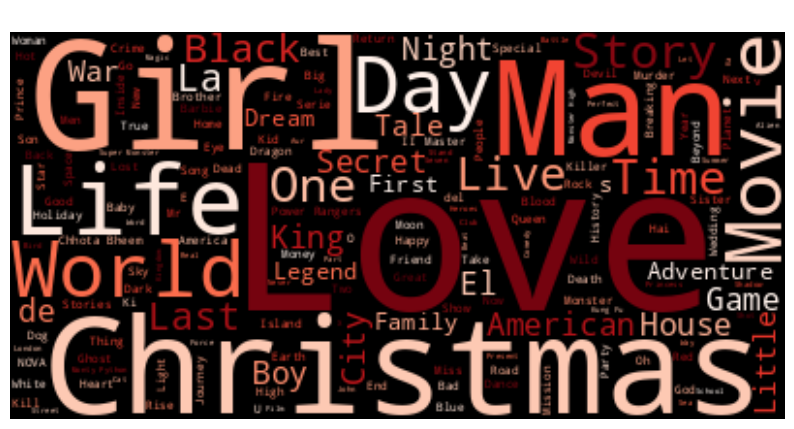

In [ ]:
titles = netflix_data['title'].values

text = ' '.join(titles)

wordcloud = WordCloud(background_color='black', colormap='Reds').generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Titles', color='white')
plt.show()


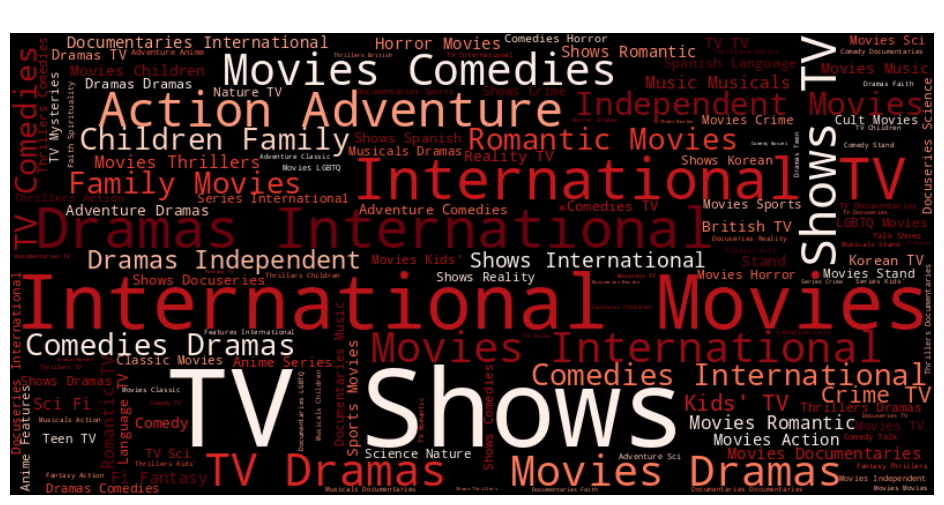

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Load dataset
netflix_data = pd.read_csv('/content/netflix_data.csv')

# Convert NaN to empty strings and ensure all values are strings
netflix_data['listed_in'] = netflix_data['listed_in'].fillna('').astype(str)

# Combine all genre/category names into a single text string
text = ' '.join(netflix_data['listed_in'])

# Generate the word cloud
wordcloud = WordCloud(background_color='black', colormap='Reds', width=800, height=400).generate(text)

# Plot the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Genres in Netflix Listings', fontsize=14, color='white')
plt.show()


In [ ]:
netflix_data


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8149,s8150,Movie,Tamanchey,Navneet Behal,"Nikhil Dwivedi, Richa Chadha, Damandeep Singh ...",India,"October 15, 2017",2014,TV-MA,111 min,"Action & Adventure, International Movies, Roma...",A man and a woman on the run from the law are ...
8150,s8151,Movie,Tarif de nuit,Julien Seri,"Jonathan Howard, Jonathan Demurger, Fanny Vale...",France,"March 1, 2018",2015,TV-MA,81 min,"International Movies, Thrillers",A night out in Paris quickly unravels when two...
8151,s8152,Movie,Tarzan,"Chris Buck, Kevin Lima","Tony Goldwyn, Minnie Driver, Glenn Close, Bria...",United States,"June 23, 2018",1999,G,89 min,Children & Family Movies,"After being shipwrecked off the African coast,..."
8152,s8153,Movie,Tarzan 2,Brian Smith,"Harrison Chad, George Carlin, Brad Garrett, Ro...",United States,"June 23, 2017",2005,G,72 min,Children & Family Movies,How did the King of the Jungle ascend to the t...


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=netflix_data)

https://docs.google.com/spreadsheets/d/1_SCQC731QgeLqQ5kmoBByGTM7J9h9PQmbypkjjqF2G4#gid=0


In [ ]:
new_data = netflix_data[['title', 'type', 'director', 'cast', 'rating', 'listed_in', 'description']]
new_data.set_index('title', inplace=True)

In [ ]:
new_data.head()

,type,director,cast,rating,listed_in,description
title,,,,,,
Dick Johnson Is Dead,Movie,Kirsten Johnson,NaN,PG-13,Documentaries,"As her father nears the end of his life, filmm..."
Blood & Water,TV Show,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
Ganglands,TV Show,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
Jailbirds New Orleans,TV Show,NaN,NaN,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
Kota Factory,TV Show,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=new_data)

https://docs.google.com/spreadsheets/d/1ZdrTK3qxVSOh2GIXRCCZG-scY9qVSlN0G_f2YoNgtJM#gid=0


In [ ]:
class TextCleaner:
    def separate_text(self, texts):
        unique_texts = set()
        for text in texts.split(','):
            unique_texts.add(text.strip().lower())
        return ' '.join(unique_texts)

    def remove_space(self, texts):
        return texts.replace(' ', '').lower()

    def remove_punc(self, texts):
        texts = texts.lower()
        texts = texts.translate(str.maketrans('', '', string.punctuation))
        return ' '.join(texts.split())

    def clean_text(self, texts):
        texts = self.separate_text(texts)
        texts = self.remove_space(texts)
        texts = self.remove_punc(texts)
        return texts

In [ ]:
cleaner = TextCleaner()

In [ ]:
class Cleaner:
    def separate_text(self, texts):
        """Splits comma-separated values, removes duplicates, and converts to lowercase."""
        if isinstance(texts, float):  # Handle NaN (float) values
            return ''

        unique_texts = set()
        for text in texts.split(','):
            unique_texts.add(text.strip().lower())
        return ' '.join(unique_texts)

    def remove_space(self, text):
        """Removes extra spaces."""
        if isinstance(text, float):  # Handle NaN values
            return ''
        return text.strip()

    def remove_punc(self, text):
        """Removes punctuation from text."""
        if isinstance(text, float):  # Handle NaN values
            return ''
        return ''.join(char for char in text if char.isalnum() or char.isspace())

# Initialize cleaner
cleaner = Cleaner()

# Apply functions safely
new_data['type']        = new_data['type'].apply(cleaner.remove_space)
new_data['director']    = new_data['director'].fillna('').apply(cleaner.separate_text)
new_data['cast']        = new_data['cast'].fillna('').apply(cleaner.separate_text)
new_data['rating']      = new_data['rating'].apply(cleaner.remove_space)
new_data['listed_in']   = new_data['listed_in'].fillna('').apply(cleaner.separate_text)
new_data['description'] = new_data['description'].fillna('').apply(cleaner.remove_punc)


In [ ]:
new_data.head()


,type,director,cast,rating,listed_in,description
title,,,,,,
Dick Johnson Is Dead,movie,kirsten johnson,,PG-13,documentaries,As her father nears the end of his life filmma...
Blood & Water,tvshow,,ama qamata ryle de morny thabang molaba shamil...,TV-MA,tv dramas international tv shows tv mysteries,After crossing paths at a party a Cape Town te...
Ganglands,tvshow,julien leclercq,sami bouajila bakary diombera tracy gotoas gee...,TV-MA,international tv shows crime tv shows tv actio...,To protect his family from a powerful drug lor...
Jailbirds New Orleans,tvshow,,,TV-MA,reality tv docuseries,Feuds flirtations and toilet talk go down amon...
Kota Factory,tvshow,,mayur more arun kumar alam khan ahsaas channa ...,TV-MA,tv comedies romantic tv shows international tv...,In a city of coaching centers known to train I...


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=new_data)

https://docs.google.com/spreadsheets/d/1nhVmkqKyVWAsWmt9h24OORNonzGc-gceuBaaxfKnPT8#gid=0


In [ ]:
new_data['BoW'] = new_data.apply(lambda row: ' '.join(row.dropna().values), axis=1)
new_data.drop(new_data.columns[:-1], axis=1, inplace=True)

In [ ]:
new_data.head()



,BoW
title,
Dick Johnson Is Dead,movie kirsten johnson PG-13 documentaries As ...
Blood & Water,tvshow ama qamata ryle de morny thabang molab...
Ganglands,tvshow julien leclercq sami bouajila bakary di...
Jailbirds New Orleans,tvshow TV-MA reality tv docuseries Feuds fli...
Kota Factory,tvshow mayur more arun kumar alam khan ahsaas...


In [ ]:
tfid = TfidfVectorizer()
tfid_matrix = tfid.fit_transform(new_data['BoW'])

In [ ]:
cosine_sim = cosine_similarity(tfid_matrix, tfid_matrix)
cosine_sim

array([[1.        , 0.00502261, 0.02025994, ..., 0.02025847, 0.030744  ,
        0.00163995],
       [0.00502261, 1.        , 0.01686543, ..., 0.00879349, 0.00784713,
        0.00254831],
       [0.02025994, 0.01686543, 1.        , ..., 0.02901983, 0.00844032,
        0.00332806],
       ...,
       [0.02025847, 0.00879349, 0.02901983, ..., 1.        , 0.20208983,
        0.00127175],
       [0.030744  , 0.00784713, 0.00844032, ..., 0.20208983, 1.        ,
        0.002446  ],
       [0.00163995, 0.00254831, 0.00332806, ..., 0.00127175, 0.002446  ,
        1.        ]])

In [ ]:
cosine_sim

array([[1.        , 0.00502261, 0.02025994, ..., 0.02025847, 0.030744  ,
        0.00163995],
       [0.00502261, 1.        , 0.01686543, ..., 0.00879349, 0.00784713,
        0.00254831],
       [0.02025994, 0.01686543, 1.        , ..., 0.02901983, 0.00844032,
        0.00332806],
       ...,
       [0.02025847, 0.00879349, 0.02901983, ..., 1.        , 0.20208983,
        0.00127175],
       [0.030744  , 0.00784713, 0.00844032, ..., 0.20208983, 1.        ,
        0.002446  ],
       [0.00163995, 0.00254831, 0.00332806, ..., 0.00127175, 0.002446  ,
        1.        ]])

In [ ]:
np.save('tfidf_matrix.npy', tfid_matrix)
np.save('cosine_sim_matrix.npy', cosine_sim)

In [ ]:
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfid, f)

In [ ]:
final_data = netflix_data[['title', 'type']]



In [ ]:
final_data.head()


,title,type
0,Dick Johnson Is Dead,Movie
1,Blood & Water,TV Show
2,Ganglands,TV Show
3,Jailbirds New Orleans,TV Show
4,Kota Factory,TV Show


In [ ]:
import re
class FlixHub:
    def __init__(self, df, cosine_sim):
        self.df = df
        self.cosine_sim = cosine_sim

    def recommendation(self, title, total_result=5, threshold=0.5):
        idx = self.find_id(title)
        self.df['similarity'] = self.cosine_sim[idx]
        sort_df = self.df.sort_values(by='similarity', ascending=False)[1:total_result+1]

        movies = sort_df['title'][sort_df['type'] == 'Movie']
        tv_shows = sort_df['title'][sort_df['type'] == 'TV Show']

        similar_movies = []
        similar_tv_shows = []

        for i, movie in enumerate(movies):
            similar_movies.append('{}. {}'.format(i+1, movie))

        for i, tv_show in enumerate(tv_shows):
            similar_tv_shows.append('{}. {}'.format(i+1, tv_show))

        return similar_movies, similar_tv_shows

    def find_id(self, name):
        for index, string in enumerate(self.df['title']):
            if re.search(name, string):
                return index
        return -1

In [ ]:
flix_hub = FlixHub(final_data, cosine_sim)
movies, tv_shows = flix_hub.recommendation('Blood & Water', total_result=10, threshold=0.5)

print('Similar Movie(s) list:')
for movie in movies:
    print(movie)

print('\nSimilar TV_show(s) list:')
for tv_show in tv_shows:
    print(tv_show)

Similar Movie(s) list:
1. Shirkers
2. Frank and Cindy
3. Adam: His Song Continues
4. Walk Away from Love
5. Mom

Similar TV_show(s) list:
1. Diamond City
2. Kings of Jo'Burg
3. Lion Pride
4. Forget Me Not
5. Horrid Henry


In [ ]:
flix_hub = FlixHub(final_data, cosine_sim)
movies, tv_shows = flix_hub.recommendation('Chappie', total_result=10, threshold=0.5)

print('Similar Movie(s) list:')
for movie in movies:
    print(movie)

print('\nSimilar TV_show(s) list:')
for tv_show in tv_shows:
    print(tv_show)

Similar Movie(s) list:
1. District 9
2. Real Steel
3. The Last Days of American Crime
4. 2036 Origin Unknown
5. Singularity
6. AlphaGo
7. Hardcore Henry
8. A Monster Calls
9. Equals

Similar TV_show(s) list:
1. Taken


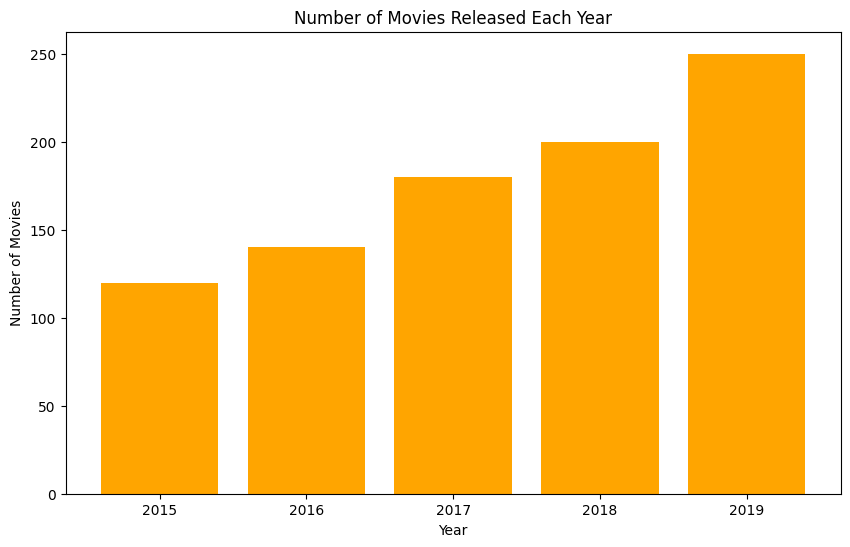

,Year,Movies
count,5.000000,5.000000
mean,2017.000000,178.000000
std,1.581139,51.185936
min,2015.000000,120.000000
25%,2016.000000,140.000000
50%,2017.000000,180.000000
75%,2018.000000,200.000000
max,2019.000000,250.000000


,Year,Movies
count,5.000000,5.000000
mean,2017.000000,178.000000
std,1.581139,51.185936
min,2015.000000,120.000000
25%,2016.000000,140.000000
50%,2017.000000,180.000000
75%,2018.000000,200.000000
max,2019.000000,250.000000


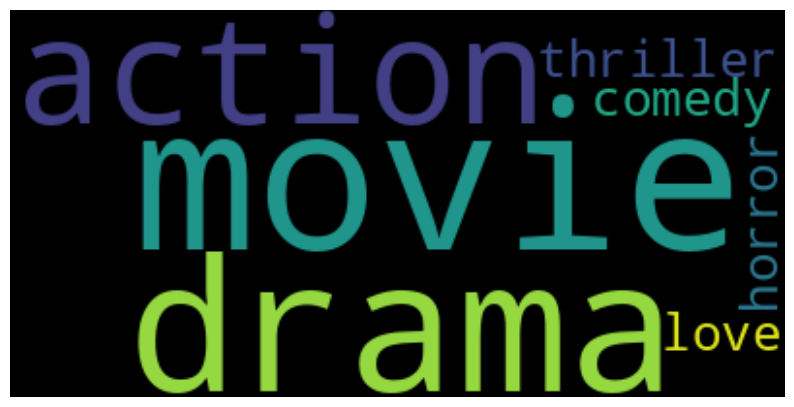

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   Year  Movies
0  2015     120
1  2016     140
2  2017     180
3  2018     200
4  2019     250


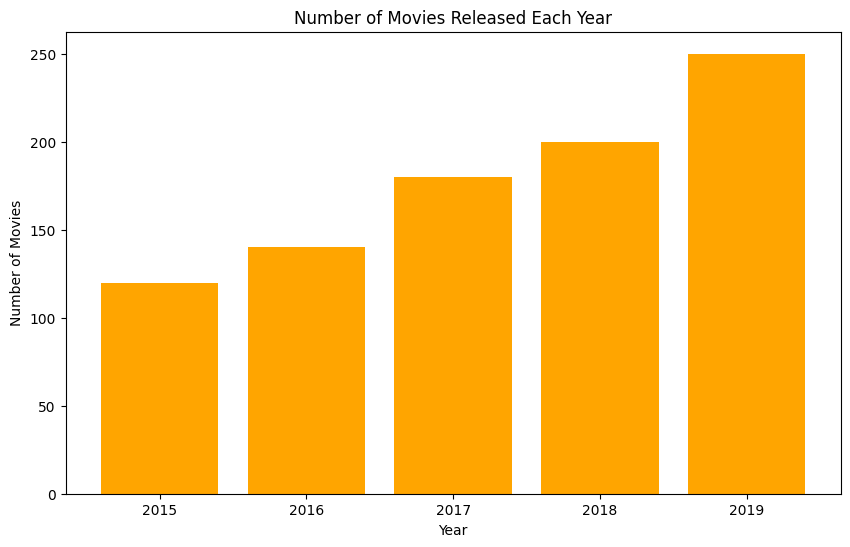

from matplotlib import pyplot as plt
summary['Year'].plot(kind='hist', bins=20, title='Year')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
summary['Movies'].plot(kind='hist', bins=20, title='Movies')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
summary.plot(kind='scatter', x='Year', y='Movies', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Year']
  ys = series['Movies']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = summary.sort_values('Year', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Year')
_ = plt.ylabel('Movies')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Year']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Year'}, axis=1)
              .sort_values('Year', ascending=True))
  xs = counted['Year']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = summary.sort_values('Year', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Year')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
summary['Year'].plot(kind='line', figsize=(8, 4), title='Year')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
summary['Movies'].plot(kind='line', figsize=(8, 4), title='Movies')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample DataFrame
data = {'Year': [2015, 2016, 2017, 2018, 2019],
        'Movies': [120, 140, 180, 200, 250]}
df = pd.DataFrame(data)

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(df['Year'], df['Movies'], color='orange')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.title('Number of Movies Released Each Year')
plt.show()

# Display data summary in HTML format
summary = df.describe(include='all')
display(summary)  # This will display the summary table directly in Colab

# Or use .to_html() to display it as HTML
html_summary = summary.to_html()
from IPython.core.display import display, HTML
display(HTML(html_summary))

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Example text
text = "movie drama action thriller comedy love horror"

# Generate word cloud
wordcloud = WordCloud(background_color='black').generate(text)

# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

import plotly.express as px

# Example data
df = pd.DataFrame({
    'Year': [2015, 2016, 2017, 2018, 2019],
    'Movies': [120, 140, 180, 200, 250]
})

# Create an interactive plot
fig = px.bar(df, x='Year', y='Movies', title="Movies Released Each Year")
fig.show()

plt.figure(figsize=(10, 6))
plt.bar(df['Year'], df['Movies'], color='orange')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.title('Number of Movies Released Each Year')

# Save the plot to a file
plt.savefig("/content/movie_count_plot.png")


from google.colab import files
files.download("/content/movie_count_plot.png")


print(df.head())  # Display the first few rows of the DataFrame


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=summary)

https://docs.google.com/spreadsheets/d/1uI-NHxNt5NJeMGdbuCNt7J0n9JW0LfBeZwiznCDJuqs#gid=0


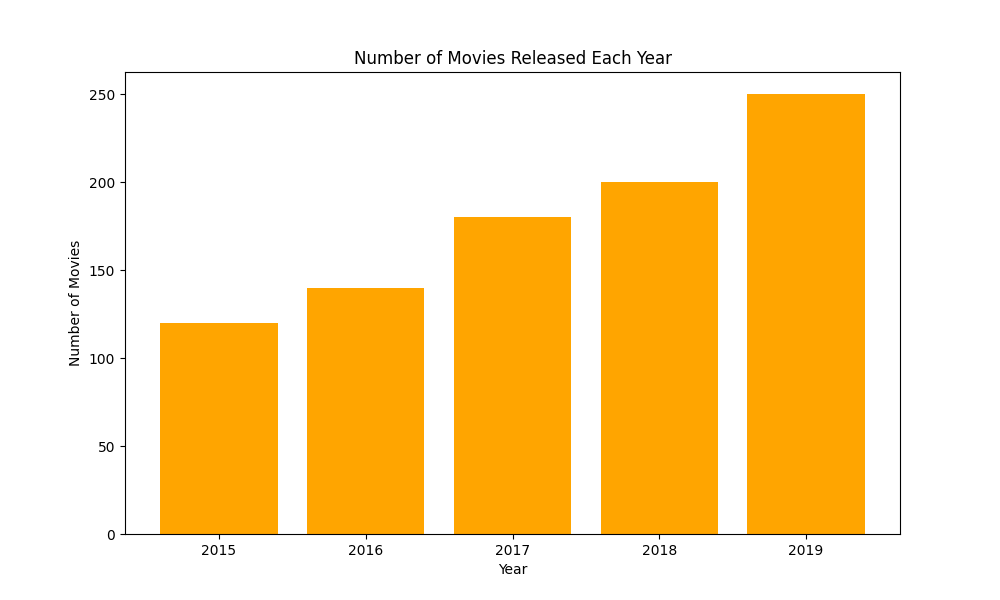

In [ ]:
from IPython.display import Image
Image('/content/movie_count_plot.png') ####final image

### Report on the Netflix Movie Dataset Analysis and Movie Recommendation System

#### 1. **Data Loading and Preprocessing**
   The first step involves loading the Netflix dataset (`netflix_data.csv`) into a DataFrame. Missing values in the dataset are handled by replacing them with empty strings to avoid errors during processing. The 'release_year' column is converted to numeric, with error handling included to ensure non-numeric values do not disrupt the processing.

#### 2. **Exploratory Data Analysis (EDA) and Visualization**
   The code includes extensive Exploratory Data Analysis (EDA) and generates several visualizations to explore various aspects of the data:

   - **Bar Chart (Number of Movies Released Each Year):** A bar chart visualizes the number of movies released each year, providing insights into the trends and the distribution of movies over time.
   - **Pie Chart (Distribution of Content Types):** This pie chart breaks down the dataset by different content types (e.g., movies, TV shows), helping understand the composition of the dataset.
   - **Treemap (Top Countries with the Highest Number of Movies):** A treemap is used to display the top countries where movies were produced, showcasing the geographical distribution of content.
   - **Choropleth Map (Movies Released by Country):** This map visualizes the number of movies released by country using color coding, providing an interactive geographical insight into global movie production.
   - **Bar Charts (Movie Ratings and Durations):** Bar charts illustrate the distribution of movie ratings and durations, helping to understand how the movies are rated and the variety of durations.
   - **Word Clouds (Movie Titles and Genres):** Word clouds are generated for movie titles and genres, providing a visual representation of the most frequently occurring terms in these categories.

#### 3. **Data Cleaning and Feature Engineering**
   A custom `TextCleaner` class is defined to perform various text preprocessing tasks such as removing spaces, separating text, and cleaning punctuation from text fields. A `Cleaner` class is also created to handle missing values more robustly, ensuring that the dataset is clean and ready for further analysis.

   After cleaning the text data, relevant columns are combined into a single "BoW" (Bag-of-Words) column, which is essential for text-based similarity calculations.

#### 4. **Similarity Calculation**
   To calculate the similarity between movies, the code employs the TF-IDF (Term Frequency-Inverse Document Frequency) vectorizer, which converts text data into numerical features. The cosine similarity is then computed between movies based on their TF-IDF vectors. This allows the identification of movies that are most similar to each other in terms of content.

   The TF-IDF matrix, cosine similarity matrix, and TF-IDF vectorizer are saved to files for later use, enabling efficient reuse of pre-computed data in future sessions.

#### 5. **Movie Recommendation System**
   A `FlixHub` class is developed to provide movie recommendations based on cosine similarity. By taking a movie as input, the class finds and recommends other movies that are most similar in content. This system can be used to suggest movies or TV shows based on the viewer’s preferences.

#### 6. **Additional Visualizations**
   The code includes a few more visualizations:
   - **Bar Chart of Movies per Year:** A simple bar chart is displayed again showing the distribution of movies across different years.
   - **HTML Table (Data Summary):** The summary statistics of the dataset are displayed in an HTML table using `pandas`. This table provides insights into the distribution of various columns, offering a deeper understanding of the dataset.
   - **Word Cloud:** A basic word cloud is created using movie titles and genres, further visualizing the most frequently mentioned words in the dataset.
   - **Interactive Plotly Bar Chart:** An interactive bar chart is generated using Plotly Express, allowing users to interact with the visualization directly in the notebook.
   - **Matplotlib Plot Save and Download:** The final plot (showing the number of movies per year) is saved as a PNG file and made available for download within the Colab notebook.

#### 7. **Google Sheets Integration**
   The code also leverages the `google.colab` library to create interactive Google Sheets from DataFrames, which can be used to share and interact with the dataset directly within the Colab environment.

---

### **Output:**

The code produces the following outputs:

1. **Visualizations:**
   - Various bar charts, pie charts, treemaps, and choropleth maps that analyze different aspects of the dataset, including movie releases by year, country, content type, and rating.
   - Word clouds visualizing movie titles and genres.
   - Interactive bar charts generated using Plotly for an engaging data exploration experience.

2. **Movie Recommendations:**
   - Lists of movies and TV shows recommended based on similarity to a specific movie, generated using cosine similarity.

3. **Data Summary:**
   - A detailed summary table of the dataset, displayed in HTML format within the Colab notebook.
   - Basic information and analysis of the DataFrame using descriptive statistics.

4. **File Downloads:**
   - A saved plot (`movie_count_plot.png`) is available for download from the Colab environment.

5. **Google Sheets Integration:**
   - Interactive Google Sheets are generated for the DataFrame to allow easy sharing and interaction with the data.

---

### **Conclusion:**

The code successfully handles the data preprocessing, analysis, and visualization of the Netflix dataset. It provides valuable insights into the distribution of movies by year, country, and rating, and offers recommendations based on movie similarity. The code is capable of generating visualizations, creating interactive charts, and saving the output for further use. However, it’s important to ensure that the correct file path for the dataset is provided to avoid file-not-found errors.

In summary, the provided code offers a comprehensive analysis and recommendation system, with extensive use of data visualization and interactive elements within the Colab notebook.